In [14]:
import pandas as pd

df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Task 1: Identify Data Quality Issues
In this step, we explore the dataset to identify missing values, data types, duplicates, and potential issues.

In [15]:
print("Shape of dataset:", df.shape)

print("\nData info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
df.describe(include='all')

Shape of dataset: (891, 12)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare            

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### Findings
- The dataset contains missing values in columns such as Age, Cabin, and Embarked.
- The dataset includes both numerical and categorical features.
- Some numerical columns, such as Fare, may contain outliers.
- No duplicate rows were found (or specify if any were found).

## Task 2: Handle Missing Values
In this step, we handle missing values using an appropriate method and explain the reason behind the chosen approach.

In [16]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [17]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column if it exists
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Explanation
- The missing values in **Age** were filled using the **median** because median is less affected by outliers.
- The missing values in **Embarked** were filled using the **mode** because it is a categorical feature.
- The **Cabin** column was dropped because it contains many missing values, which makes imputation less reliable.

## Task 3: Detect and Handle Outliers Using IQR
In this step, we detect and handle outliers in the Fare column using the IQR method.

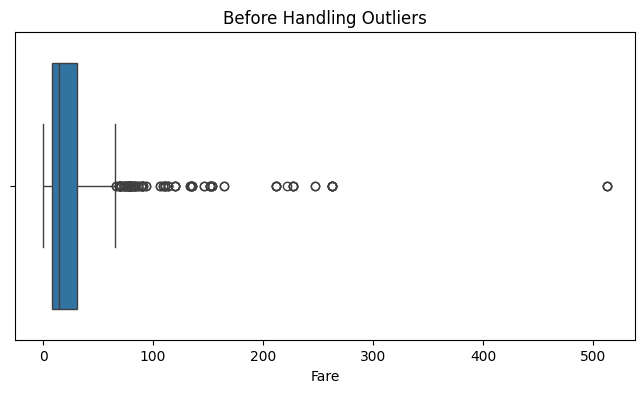

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'])
plt.title("Before Handling Outliers")
plt.show()

In [19]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 116


In [20]:
print("Before:", df.shape)

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

print("After:", df.shape)

Before: (891, 11)
After: (775, 11)


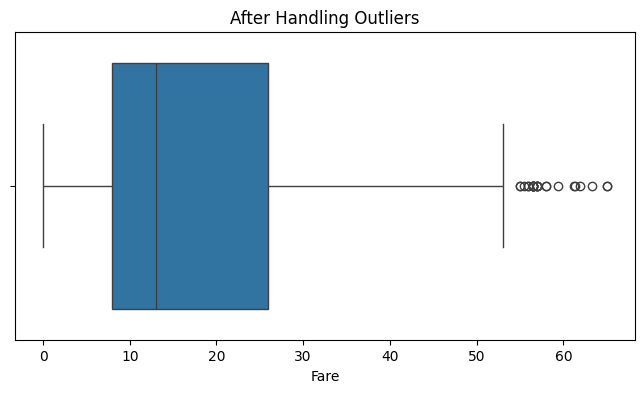

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'])
plt.title("After Handling Outliers")
plt.show()

### Explanation
The IQR method was used to detect outliers in the Fare column. Values outside the lower and upper bounds were considered outliers and removed from the dataset.

## Task 4: Normalize Numerical Features
In this step, we apply Min-Max and Z-score normalization to numerical features.

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max
minmax = MinMaxScaler()
df[['Age_MinMax', 'Fare_MinMax']] = minmax.fit_transform(df[['Age', 'Fare']])

# Z-score
zscore = StandardScaler()
df[['Age_Zscore', 'Fare_Zscore']] = zscore.fit_transform(df[['Age', 'Fare']])

df[['Age', 'Fare', 'Age_MinMax', 'Fare_MinMax', 'Age_Zscore', 'Fare_Zscore']].head()

,Age,Fare,Age_MinMax,Fare_MinMax,Age_Zscore,Fare_Zscore
0,22.0,7.2500,0.271174,0.111538,-0.528321,-0.779117
2,26.0,7.9250,0.321438,0.121923,-0.215182,-0.729373
3,35.0,53.1000,0.434531,0.816923,0.489381,2.599828
4,35.0,8.0500,0.434531,0.123846,0.489381,-0.720161
5,28.0,8.4583,0.346569,0.130128,-0.058613,-0.690071


### Explanation
- Min-Max normalization scales values between 0 and 1.
- Z-score normalization standardizes values based on mean and standard deviation.
- Both methods were applied to numerical features (Age and Fare) to improve data consistency.

## Task 5: Correlation Check and PCA
In this step, we check the correlation between numerical features and apply PCA if necessary.

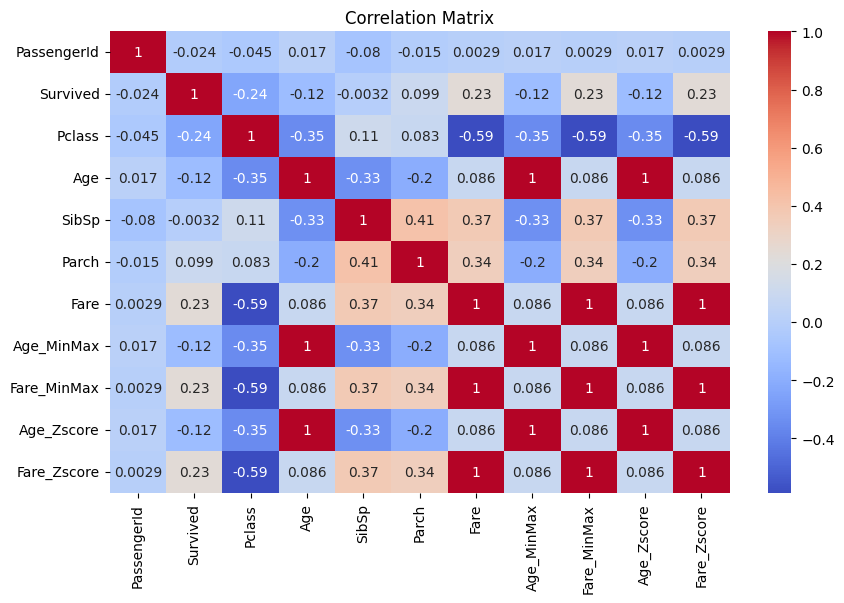

In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = df[['Age', 'Fare', 'SibSp', 'Parch']]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Shape:", pca_result.shape)

Explained variance ratio: [0.46018773 0.27244933]
Shape: (775, 2)


### Explanation
The correlation between numerical features was examined using a heatmap. Based on the observed relationships, PCA was applied to reduce the dimensionality of the dataset while preserving important information.